In [1]:
from heapq import heappop, heappush
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from utils import ucs, gbfs, astar, haversine_km, load_openflights

ROOT = Path.cwd().parent
DATA = ROOT / "all_datasets"
RESULTS = ROOT / "results" / "lab02"
RESULTS.mkdir(parents=True, exist_ok=True)

_, _, coords, graph, _ = load_openflights(DATA / "lab01-03_airports.csv", DATA / "lab01-03_routes.csv")
queries = pd.read_csv("utils/search_queries.csv").head(3)
display(queries)

,query_id,start,goal
0,Q1,KUL,KEF
1,Q2,SIN,EZE
2,Q3,NRT,CPT


In [2]:
def report(name, query, result):
    print(f"{query.query_id} {name:<5} {result.path_cost_km:>9,.1f} km "
          f"{result.expanded:>5} expanded {' -> '.join(result.path)}")

baseline = {}
for query in queries.itertuples():
    baseline[query.query_id] = ucs(graph, query.start, query.goal)
    report("UCS", query, baseline[query.query_id])

Q1 UCS    11,461.3 km  1851 expanded KUL -> HKT -> LED -> HEL -> KEF
Q2 UCS    17,817.4 km  3002 expanded SIN -> JNB -> GRU -> EZE
Q3 UCS    14,813.3 km  3042 expanded NRT -> HKG -> MRU -> CPT


In [3]:
def heuristic_to(goal, weight=1.0):
    def h(airport):
        return weight * haversine_km(coords[airport]["latitude"], coords[airport]["longitude"],
                                     coords[goal]["latitude"], coords[goal]["longitude"])
    return h

informed = {}
for query in queries.itertuples():
    h = heuristic_to(query.goal)
    informed[query.query_id, "GBFS"] = gbfs(graph, query.start, query.goal, h)
    informed[query.query_id, "A*"]   = astar(graph, query.start, query.goal, h)
    report("GBFS", query, informed[query.query_id, "GBFS"])
    report("A*",   query, informed[query.query_id, "A*"])

Q1 GBFS   12,500.5 km     2 expanded KUL -> LHR -> KEF
Q1 A*     11,461.3 km    69 expanded KUL -> HKT -> LED -> HEL -> KEF
Q2 GBFS   17,817.4 km     3 expanded SIN -> JNB -> GRU -> EZE
Q2 A*     17,817.4 km   151 expanded SIN -> JNB -> GRU -> EZE
Q3 GBFS   15,811.3 km     3 expanded NRT -> DOH -> JNB -> CPT
Q3 A*     14,813.3 km    63 expanded NRT -> HKG -> MRU -> CPT


In [5]:
def reverse(graph):
    reversed_graph = {airport: [] for airport in graph}
    for airport, neighbours in graph.items():
        for neighbour, cost in neighbours:
            reversed_graph[neighbour].append((airport, cost))
    return reversed_graph

def cost_to_all(graph, start):
    """Dijkstra: cheapest cost from start to every reachable state."""
    best = {start: 0.0}
    frontier = [(0.0, start)]
    while frontier:
        cost, state = heappop(frontier)
        if cost > best[state]:
            continue
        for neighbour, edge in graph[state]:
            if cost + edge < best.get(neighbour, np.inf):
                best[neighbour] = cost + edge
                heappush(frontier, (cost + edge, neighbour))
    return best 

In [6]:
reversed_graph = reverse(graph)
checks = []
for query in queries.itertuples():
    exact = cost_to_all(reversed_graph, query.goal)   # true cost-to-goal for every airport
    h = heuristic_to(query.goal)
    airports = sorted((a for a in exact if a != query.goal), key=exact.get)
    for airport in [airports[i] for i in np.linspace(0, len(airports) - 1, 10, dtype=int)]:
        checks.append({"query_id": query.query_id, "airport": airport, "goal": query.goal,
                       "haversine_km": h(airport), "shortest_route_km": exact[airport]})

check = pd.DataFrame(checks)
check["slack_km"] = check.shortest_route_km - check.haversine_km
check["admissible"] = check.slack_km >= -1e-6
check.to_csv(RESULTS / "heuristic_check.csv", index=False)
print("Admissibility violations:", int((~check.admissible).sum()), "of", len(check))
display(check.head(10).round(1))

Admissibility violations: 0 of 30


,query_id,airport,goal,haversine_km,shortest_route_km,slack_km,admissible
0,Q1,GLA,KEF,1347.5,1347.5,0.0,True
1,Q1,IBZ,KEF,3206.4,3244.5,38.1,True
2,Q1,GZP,KEF,4744.9,4745.7,0.8,True
3,Q1,TUU,KEF,5710.9,5847.1,136.2,True
4,Q1,OAK,KEF,6731.3,6893.0,161.8,True
5,Q1,ANC,KEF,5424.4,8137.0,2712.5,True
6,Q1,JSR,KEF,8696.8,9238.7,541.9,True
7,Q1,AKY,KEF,9163.0,10503.7,1340.7,True
8,Q1,ZCO,KEF,12238.3,12935.8,697.4,True
9,Q1,OTD,KEF,7561.2,30818.5,23257.4,True


In [7]:
rows = []
for query in queries.itertuples():
    results = {"UCS": baseline[query.query_id],
               "GBFS": informed[query.query_id, "GBFS"],
               "A*": informed[query.query_id, "A*"]}
    for name, result in results.items():
        rows.append({"query_id": query.query_id, "algorithm": name,
                     **result.as_dict(), "path": " -> ".join(result.path)})

metrics = pd.DataFrame(rows).drop(columns="found").rename(columns={"path_cost_km": "cost_km"})
ucs_cost = metrics[metrics.algorithm == "UCS"].set_index("query_id").cost_km
metrics["gap_pct"] = 100 * (metrics.cost_km / metrics.query_id.map(ucs_cost) - 1)
display(metrics.drop(columns="path").round(2))

ucs_rows, astar_rows = metrics[metrics.algorithm == "UCS"], metrics[metrics.algorithm == "A*"]
print("A* matches UCS on every query:", np.allclose(ucs_rows.cost_km.values, astar_rows.cost_km.values))
print("Mean A* expansion reduction vs UCS: {:.1%}".format(1 - astar_rows.expanded.mean() / ucs_rows.expanded.mean()))

,query_id,algorithm,hops,cost_km,expanded,max_frontier,runtime_ms,gap_pct
0,Q1,UCS,4,11461.35,1851,616,56.60,0.00
1,Q1,GBFS,2,12500.50,2,246,25.81,9.07
2,Q1,A*,4,11461.35,69,409,37.25,0.00
3,Q2,UCS,3,17817.36,3002,620,66.09,0.00
4,Q2,GBFS,3,17817.36,3,262,21.16,0.00
5,Q2,A*,3,17817.36,151,330,23.96,0.00
6,Q3,UCS,3,14813.32,3042,1018,59.68,0.00
7,Q3,GBFS,3,15811.29,3,234,20.36,6.74
8,Q3,A*,3,14813.32,63,496,29.77,0.00


A* matches UCS on every query: True
Mean A* expansion reduction vs UCS: 96.4%


In [8]:
weighted = []
for query in queries.itertuples():
    result = astar(graph, query.start, query.goal, heuristic_to(query.goal, weight=1.5))
    weighted.append({"query_id": query.query_id, "algorithm": "Weighted A* (1.5h)",
                     **result.as_dict(), "path": " -> ".join(result.path)})

weighted = pd.DataFrame(weighted).drop(columns="found").rename(columns={"path_cost_km": "cost_km"})
weighted["gap_pct"] = 100 * (weighted.cost_km / weighted.query_id.map(ucs_cost) - 1)
metrics = pd.concat([metrics, weighted], ignore_index=True)
metrics.to_csv(RESULTS / "metrics.csv", index=False)

display(metrics[metrics.algorithm != "GBFS"][["query_id", "algorithm", "cost_km", "gap_pct", "expanded"]].round(2))

,query_id,algorithm,cost_km,gap_pct,expanded
0,Q1,UCS,11461.35,0.00,1851
2,Q1,A*,11461.35,0.00,69
3,Q2,UCS,17817.36,0.00,3002
5,Q2,A*,17817.36,0.00,151
6,Q3,UCS,14813.32,0.00,3042
8,Q3,A*,14813.32,0.00,63
9,Q1,Weighted A* (1.5h),12274.32,7.09,2
10,Q2,Weighted A* (1.5h),17817.36,0.00,3
11,Q3,Weighted A* (1.5h),14929.35,0.78,4


Saved: ['expanded_nodes.png', 'heuristic_check.csv', 'metrics.csv']


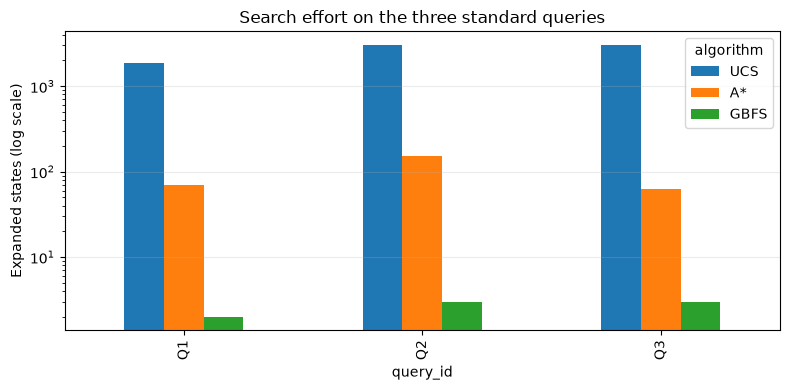

In [9]:
effort = metrics[metrics.algorithm.isin(["UCS", "A*", "GBFS"])].pivot(
    index="query_id", columns="algorithm", values="expanded")

ax = effort[["UCS", "A*", "GBFS"]].plot.bar(figsize=(8, 4), logy=True)
ax.set(ylabel="Expanded states (log scale)", title="Search effort on the three standard queries")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS / "expanded_nodes.png", dpi=160)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))